In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import glob
import csv
import ast
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [84]:
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

In [162]:
x2name

{'1': 'cradle loop barrel',
 '2': 'OB-fold',
 '4': 'SH3',
 '5': 'beta-propeller-like',
 '9': 'Lipocalins/Streptavidin',
 '10': 'jelly-roll',
 '11': 'Immunoglobulin-like beta-sandwich',
 '12': 'Glycosyl hydrolase domain-like',
 '56': 'Epsilon subunit of F1F0-ATP synthase-N',
 '58': 'Oncogene product-like',
 '60': 'SPOC domain-like',
 '64': 'WW domain-like',
 '70': 'beta-clip',
 '71': 'Lipoprotein localization factors LolAB',
 '77': 'open-sided beta-meander',
 '101': 'HTH',
 '102': 'HhH/H2TH',
 '103': 'RuvA-C',
 '105': 'HLH-like',
 '107': 'Cytochrome c-like',
 '108': 'EF-hand',
 '109': 'Repetitive alpha hairpins',
 '110': 'DEATH domain',
 '130': 'LEM/SAP HeH motif-like',
 '131': 'PDEase-like',
 '132': 'ACP-like',
 '133': 'DH domain-like',
 '139': 'Multiheme cytochromes',
 '142': 'Sigma2 domain-like',
 '143': 'PABP domain-like',
 '148': 'Histone-like',
 '150': 'Ferritin/Heme oxygenase/4-helical cytokines',
 '165': 'Dimerisation interlock',
 '170': 'Retrovirus capsid protein',
 '172': 'Cit

# Inspecting the LOO (Leave One Out) data

- number of files in fold_results = **399** (= 397 xgroups + 'independent' and 'spontaneous')

- **node** = cpds (total: **4318**)

- **edge** = reactions = rules (set of folds)


Let's check one file to get what we're looking for

# New model:

- number of files in fold_results = **398** (= 396 xgroups + 'independent' and 'spontaneous')

- **node** = cpds (total: **4291**)

- **edge** = reactions = rules (set of folds)

In [3]:
# wo2002 ('without' 2002)
wo2002 = pd.read_pickle('../LOO/2024-06-06_18-18-38__2002.pkl.gz')

# cpds_cumiter = {'C00036': 0...}  len: 4318   range: 0-89
# cpds_folditer = {'C00036': 0...}  len: 4318   range: 0-2
# cpds_subiter = [{'C00036': 0...}, {'C00311': 0...}, {'C06032': 0...}]  len: 80, 155, 4315; range: 0, 0-4, 0-84

# final_path = None
# iteration = 3

# folds_cumiter = {'2003': 0...}  len: 399; range: 0 or 1 (self = 6)
# folds_folditer = {'2003': 0...}  len: 399; range: 0-2

- **cpds_subiter** is a list with 3 (or 2) dictionaries
- *first dictionary* is always len = **80**<br>
- *second dictionary* has variable lengths = **155-4315**<br>
- *third dictionary* is either len = **4315** or it doesn't exist if len = 4315 in second dictionary<br>

- the second dictionary **cpds_subiter[1]** is what we're looking for<br>

## Create dict 'loo' with all Leave One Out results

In [4]:
folder_path = '../LOO_propero/'
files_pattern = '*.pkl.gz'
files = glob.glob(folder_path + files_pattern)

loo = {}

# Iterate over each file
for file_path in files:
    # Extract the fold number from the file name
    fold_number = file_path.split('__')[1].split('.')[0]
    
    # Read the pickle file and populate loo dictionary
    loo[fold_number] = pd.read_pickle(file_path)
    print(fold_number)

102
3086
4022
3579
5100
2005
285
2010
4952
4295
221
611
4110
7528
868
301
184
7553
1077
7556
4017
313
4019
3687
325
6096
7549
177
7601
3257
4028
131
199
7536
3651
258
4035
214
7512
867
10
3978
243
1137
6051
3323
7539
323
4018
107
7561
2487
3016
7602
309
3001
146
2003
387
282
283
4178
2002
7523
144
6166
328
244
4159
217
5084
7546
3500
3599
4076
7517
3304
3994
3371
7580
806
842
236
279
4054
1144
650
528
3752
3654
3321
241
3754
262
3686
7516
623
5
7513
232
3858
286
2011
4049
7581
3076
314
875
3264
312
159
303
632
4335
3456
222
810
1114
2498
4262
7564
602
4114
3896
11
192
230
2496
911
2
205
4161
2486
277
377
378
4272
132
805
7572
307
108
881
4081
3339
3691
284
212
4045
2006
7588
4029
268
4011
239
7604
9
590
7522
5069
3843
64
7574
4044
6113
7509
2484
62
813
6
3697
315
7500
218
3692
3249
3892
7542
319
581
503
4294
1074
4194
2004
3847
304
296
374
208
275
812
873
7521
620
3623
70
324
6174
150
1055
2008
7584
206
298
525
4953
708
3688
582
640
235
7562
5039
3322
7567
5038
375
164
7525
3294
149
75

## Collect the network sizes in subiter

In [5]:
subiter0 = []
for xgroup in loo:
    if xgroup != 'spontaneous':
        subiter0.append(len(loo[xgroup].cpds_subiter[0]))

In [6]:
subiter1 = []
for xgroup in loo:
    if xgroup != 'spontaneous':
        subiter1.append(len(loo[xgroup].cpds_subiter[1]))

In [7]:
subiter2 = []
for xgroup in loo:
    if xgroup != 'spontaneous':
        try:
            subiter2.append(len(loo[xgroup].cpds_subiter[2]))
        except:
            subiter2.append(None)

## histogram of network sizes

In [9]:
np.max(subiter1)

4291

In [10]:
max = list(filter(lambda x: x == np.max(subiter1), subiter1))
len(max)

188

In [11]:
# create xgroup2networkSize dict

xgroup2ns = {}
for xgroup in loo:
    if xgroup not in ['spontaneous', 'fold_independent']:
        xgroup2ns[xgroup] = len(loo[xgroup].cpds_subiter[1])

<function matplotlib.pyplot.show(close=None, block=None)>

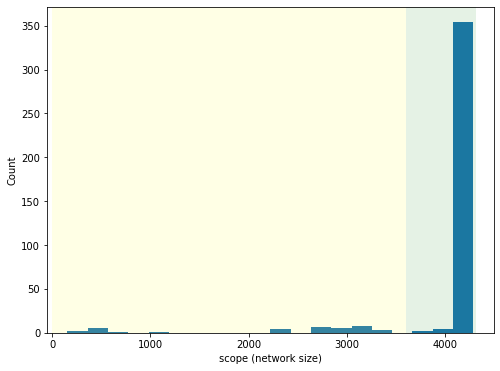

In [8]:
# Let's look at the distribution of network sizes

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.hist(subiter1, bins = 20)
ax.axvspan(0, 3600, facecolor='yellow', alpha=0.1)
ax.axvspan(3600, 4315, facecolor='green', alpha=0.1)
ax.set_xlabel('scope (network size)')
ax.set_ylabel('Count')

# plt.savefig('loo_histogram.png')
plt.show

In [12]:
xgroup2ns

{'102': 4290,
 '3086': 4290,
 '4022': 4290,
 '3579': 4291,
 '5100': 4291,
 '2005': 645,
 '285': 4291,
 '2010': 4289,
 '4952': 457,
 '4295': 4291,
 '221': 4156,
 '611': 4291,
 '4110': 4291,
 '7528': 4291,
 '868': 4291,
 '301': 4275,
 '184': 3046,
 '7553': 4249,
 '1077': 4291,
 '7556': 4291,
 '4017': 4291,
 '313': 4291,
 '4019': 4289,
 '3687': 4291,
 '325': 555,
 '6096': 4291,
 '7549': 4289,
 '177': 4291,
 '7601': 4291,
 '3257': 4291,
 '4028': 4291,
 '131': 4291,
 '199': 4289,
 '7536': 4291,
 '3651': 4291,
 '258': 4291,
 '4035': 4291,
 '214': 4291,
 '7512': 4095,
 '867': 4286,
 '10': 4017,
 '3978': 4286,
 '243': 4249,
 '1137': 4232,
 '6051': 4281,
 '3323': 4291,
 '7539': 4291,
 '323': 4192,
 '4018': 4270,
 '107': 4290,
 '7561': 4263,
 '2487': 4250,
 '3016': 2687,
 '7602': 4291,
 '309': 4291,
 '3001': 4291,
 '146': 4270,
 '2003': 1014,
 '387': 4291,
 '282': 4285,
 '283': 4291,
 '4178': 4291,
 '2002': 155,
 '7523': 2901,
 '144': 4291,
 '6166': 4284,
 '328': 2831,
 '244': 4102,
 '4159': 429

In [13]:
len(xgroup2ns)

396

In [16]:
# dict2csv(xgroup2ns, '../data/assets/xgroup2/xgroup2networkSize_after.csv')

In [17]:
xgroup2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize_after.csv')

## Separate into group1, group2

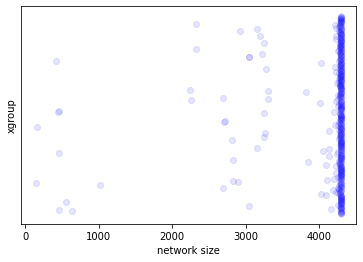

In [18]:
plt.scatter(xgroup2ns.values(), xgroup2ns.keys(), marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('network size')
plt.ylabel('xgroup')
plt.yticks([])
plt.show()

In [19]:
# look at network size < 1500

xgroup2sub1500 = {}
xgroup2sup1500 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 1500:
        xgroup2sub1500[xgroup] = xgroup2ns[xgroup]
    else:
        xgroup2sup1500[xgroup] = xgroup2ns[xgroup]

In [20]:
# look at network size < 3600

groupOne2ns = {}
groupTwo2ns = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        groupOne2ns[xgroup] = xgroup2ns[xgroup]
    else:
        groupTwo2ns[xgroup] = xgroup2ns[xgroup]

In [21]:
first10 = list(xgroup2sub1500.keys())
group1 = list(groupOne2ns.keys())
group2 = list(groupTwo2ns.keys())

In [22]:
first10

['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

In [23]:
print(group1)

['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']


In [24]:
len(group1)

37

### difference with old model?

In [25]:
first10_old = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
group1_old = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}
group2_old = {'7553', '2487', '147', '2011', '4048', '136', '2493', '4004', '217', '210', '911', '3847', '133', '313', '881', '7514', '131', '7550', '603', '4335', '300', '268', '231', '302', '2012', '2006', '323', '7558', '275', '69', '139', '6', '708', '257', '7540', '3740', '331', '7568', '246', '4022', '2484', '3994', '209', '7586', '7549', '6174', '4159', '12', '7589', '3005', '7561', '1114', '4029', '3292', '284', '7500', '3599', '557', '1055', '239', '4018', '2485', '7581', '3156', '3321', '6094', '150', '3294', '7525', '7539', '7513', '3892', '7512', '4', '4971', '230', '5039', '5038', '623', '702', '620', '4093', '3304', '7522', '107', '830', '3447', '5103', '376', '3339', '158', '319', '3264', '102', '3456', '144', '633', '914', '7552', '880', '236', '355', '842', '377', '7517', '4995', '4237', '62', '11', '6166', '221', '298', '3374', '220', '197', '375', '189', '4049', '205', '806', '219', '3993', '3692', '132', '7518', '3688', '813', '7510', '283', '6075', '316', '812', '503', '4279', '315', '228', '4076', '281', '7520', '307', '3685', '324', '374', '1119', '172', '309', '154', '3076', '7509', '4114', '2498', '525', '7542', '207', '7529', '1137', '876', '73', '185', '70', '4052', '4002', '5', '3686', '3579', '650', '129', '3207', '4046', '608', '296', '611', '7516', '243', '7551', '312', '1074', '4178', '222', '5069', '65', '3623', '3001', '3777', '810', '7573', '279', '6096', '4126', '805', '3699', '2500', '276', '3500', '6051', '3858', '5100', '6113', '604', '371', '306', '180', '179', '7595', '7528', '4028', '258', '2', '4019', '1144', '814', '3794', '7588', '66', '75', '108', '528', '1001', '582', '3883', '3371', '7521', '7543', '3086', '920', '285', '3697', '3115', '3323', '241', '4194', '232', '4017', '303', '7531', '5104', '278', '7504', '1143', '244', '6058', '4160', '7546', '378', '2010', '321', '64', '211', '3269', '301', '2008', '7587', '4024', '5084', '7524', '305', '868', '106', '3978', '3322', '4111', '590', '214', '7564', '4044', '10', '3843', '865', '270', '3281', '196', '4161', '213', '7562', '192', '7541', '103', '3691', '7515', '4035', '3052', '3896', '237', '1077', '3960', '7560', '262', '3117', '7604', '7', '4983', '7578', '4229', '4295', '387', '2496', '4045', '4020', '277', '266', '159', '286', '4294', '3009', '4033', '7580', '7601', '5067', '7527', '282', '3018', '7554', '4262', '4272', '7571', '146', '7567', '223', '872', '247', '7507', '601', '314', '9', '7572', '869', '4025', '4036', '235', '581', '3752', '149', '3754', '640', '7602', '199', '208', '4081', '7534', '187', '7556', '3654', '3651', '169', '873', '867', '4021', '3249', '164', '7536', '7563', '629', '632', '4054', '558', '3687', '4110', '177', '3257', '4223'}

In [26]:
first10_old == set(first10)

True

In [27]:
group1_old - set(group1)
# Tryptophan folds (X184, X7544) and Arginine fold (X253)!

set()

# rn2rules

In [28]:
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')

In [29]:
def numRulesWith(xgroup, rn2rules):
    numRules = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

In [30]:
numRulesWith('2003', rn2rules)

3071

In [31]:
x2rulesNum = {}
for xgroup in xgroup2ns.keys():
    x2rulesNum[xgroup] = numRulesWith(xgroup, rn2rules)

In [32]:
list(x2rulesNum.items())

[('102', 56),
 ('3086', 3),
 ('4022', 2),
 ('3579', 9),
 ('5100', 13),
 ('2005', 128),
 ('285', 2),
 ('2010', 18),
 ('4952', 25),
 ('4295', 1),
 ('221', 346),
 ('611', 4),
 ('4110', 6),
 ('7528', 32),
 ('868', 12),
 ('301', 108),
 ('184', 23),
 ('7553', 3),
 ('1077', 4),
 ('7556', 6),
 ('4017', 10),
 ('313', 4),
 ('4019', 15),
 ('3687', 45),
 ('325', 229),
 ('6096', 1),
 ('7549', 4),
 ('177', 10),
 ('7601', 2),
 ('3257', 5),
 ('4028', 5),
 ('131', 105),
 ('199', 4),
 ('7536', 4),
 ('3651', 3),
 ('258', 6),
 ('4035', 8),
 ('214', 22),
 ('7512', 406),
 ('867', 17),
 ('10', 679),
 ('3978', 14),
 ('243', 243),
 ('1137', 44),
 ('6051', 4),
 ('3323', 109),
 ('7539', 4),
 ('323', 131),
 ('4018', 31),
 ('107', 70),
 ('7561', 19),
 ('2487', 193),
 ('3016', 386),
 ('7602', 2),
 ('309', 4),
 ('3001', 1),
 ('146', 50),
 ('2003', 3071),
 ('387', 10),
 ('282', 12),
 ('283', 8),
 ('4178', 31),
 ('2002', 1833),
 ('7523', 19),
 ('144', 2),
 ('6166', 7),
 ('328', 23),
 ('244', 517),
 ('4159', 6),
 ('217

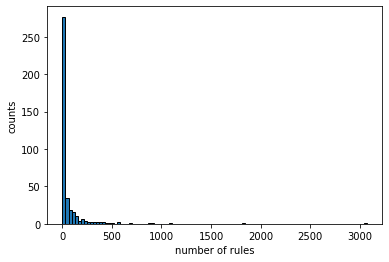

In [33]:
histogram(x2rulesNum, bins=100, x_axis = 'number of rules')

In [34]:
# dict2csv(x2rulesNum, 'xgroup2rulesNum.csv')

# Unique Reactions
A reaction is UNIQUE to that fold if that fold appears in ALL rules associated with the reaction

In [35]:
# R1: {{2002}, {2002, 2}, {2002, 3}}
# then R1 is "unique" to 2002

In [36]:
# fraction
def numUniqueReactionWith(xgroup, rn2rules):
    result = {'unique':[], 'total':[]}
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1              
            if counter == len(rules):
                result['unique'].append(reaction)
                result['total'].append(reaction)
            elif xgroup in rule:
                result['total'].append(reaction)
    return result

In [37]:
x2uniqueTotal = {}
for xgroup in xgroup2ns.keys():
    x2uniqueTotal[xgroup] = numUniqueReactionWith(xgroup, rn2rules)
x2fractionUnique = {}
for xgroup in xgroup2ns.keys():
        x2fractionUnique[xgroup] = len(x2uniqueTotal[xgroup]['unique'])/len(x2uniqueTotal[xgroup]['total'])

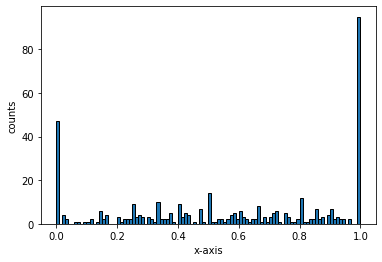

In [38]:
histogram(x2fractionUnique, 'fraction unique', bins=100)

In [39]:
setUniqueX = set()
for x, frac in x2fractionUnique.items():
    if frac > 0.5:  # Unique - threshold? 0.0? 0.5? //// 0.8? (reversed)
        if x != 'spontaneous':
            setUniqueX.add(x)

In [40]:
len(setUniqueX)

223

### Group 1

In [41]:
len(group1)

37

In [42]:
len(set(group1) & setUniqueX)

29

In [43]:
len(set(group1) & setUniqueX) / len(set(group1))

0.7837837837837838

### Group 2

In [44]:
len(set(group2) & setUniqueX)

194

In [45]:
len(set(group2))

359

In [46]:
len(set(group2) & setUniqueX) / len(set(groupTwo2ns.keys()))

0.5403899721448467

# Independent Rules/Reactions

In [47]:
def numIndepRuleWith(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule

In [48]:
ex_dict = {}
ex_dict['a'] = {frozenset({'1'})}  # yes1
ex_dict['b'] = {frozenset({'1'}), frozenset({'2'})}  # yes1, yes2
ex_dict['c'] = {frozenset({'1', '2'})}  # no1, no2
ex_dict['d'] = {frozenset({'1', '2'}), frozenset({'1'})}  # yes1, no2
ex_dict['e'] = {frozenset({'1', '2'}), frozenset({'7'})}  # no1, no2; yes7

print(numIndepRuleWith('1',ex_dict))  # 3
print(numIndepRuleWith('2',ex_dict))  # 1
print(numIndepRuleWith('7',ex_dict))  # 1

3
1
1


In [49]:
numIndepRuleWith('2003', rn2rules)

1284

In [50]:
x2indepRulesNum = {}
for xgroup in xgroup2ns.keys():
    x2indepRulesNum[xgroup] = numIndepRuleWith(xgroup, rn2rules)

In [51]:
x2indepRulesNum

{'102': 0,
 '3086': 3,
 '4022': 0,
 '3579': 0,
 '5100': 0,
 '2005': 51,
 '285': 2,
 '2010': 6,
 '4952': 0,
 '4295': 1,
 '221': 117,
 '611': 0,
 '4110': 1,
 '7528': 13,
 '868': 11,
 '301': 28,
 '184': 0,
 '7553': 2,
 '1077': 0,
 '7556': 0,
 '4017': 0,
 '313': 0,
 '4019': 1,
 '3687': 0,
 '325': 9,
 '6096': 0,
 '7549': 4,
 '177': 0,
 '7601': 0,
 '3257': 0,
 '4028': 0,
 '131': 56,
 '199': 0,
 '7536': 0,
 '3651': 0,
 '258': 0,
 '4035': 0,
 '214': 0,
 '7512': 387,
 '867': 17,
 '10': 409,
 '3978': 12,
 '243': 47,
 '1137': 0,
 '6051': 0,
 '3323': 0,
 '7539': 4,
 '323': 78,
 '4018': 0,
 '107': 19,
 '7561': 17,
 '2487': 27,
 '3016': 34,
 '7602': 0,
 '309': 2,
 '3001': 0,
 '146': 28,
 '2003': 1284,
 '387': 0,
 '282': 1,
 '283': 2,
 '4178': 0,
 '2002': 796,
 '7523': 10,
 '144': 0,
 '6166': 0,
 '328': 2,
 '244': 73,
 '4159': 0,
 '217': 34,
 '5084': 37,
 '7546': 0,
 '3500': 0,
 '3599': 0,
 '4076': 0,
 '7517': 18,
 '3304': 0,
 '3994': 0,
 '3371': 6,
 '7580': 2,
 '806': 0,
 '842': 2,
 '236': 11,
 '279

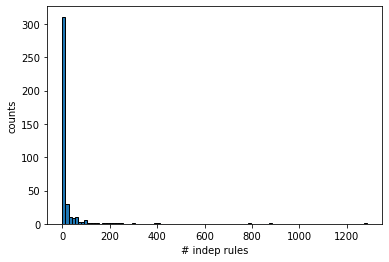

In [52]:
histogram(x2indepRulesNum, x_axis='# indep rules' ,bins=100)

In [53]:
# dict2csv(x2indepRulesNum, 'xgroup2IndepRulesNum.csv')

In [54]:
# fraction

def numIndepRuleWith2(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule / numRulesWith(xgroup, rn2rules)

In [55]:
numIndepRuleWith2('2003', rn2rules)

0.4181048518397916

In [56]:
x2indepRulesFraction = {}
for xgroup in xgroup2ns.keys():
    x2indepRulesFraction[xgroup] = numIndepRuleWith2(xgroup, rn2rules)

In [57]:
x2indepRulesFraction

{'102': 0.0,
 '3086': 1.0,
 '4022': 0.0,
 '3579': 0.0,
 '5100': 0.0,
 '2005': 0.3984375,
 '285': 1.0,
 '2010': 0.3333333333333333,
 '4952': 0.0,
 '4295': 1.0,
 '221': 0.33815028901734107,
 '611': 0.0,
 '4110': 0.16666666666666666,
 '7528': 0.40625,
 '868': 0.9166666666666666,
 '301': 0.25925925925925924,
 '184': 0.0,
 '7553': 0.6666666666666666,
 '1077': 0.0,
 '7556': 0.0,
 '4017': 0.0,
 '313': 0.0,
 '4019': 0.06666666666666667,
 '3687': 0.0,
 '325': 0.039301310043668124,
 '6096': 0.0,
 '7549': 1.0,
 '177': 0.0,
 '7601': 0.0,
 '3257': 0.0,
 '4028': 0.0,
 '131': 0.5333333333333333,
 '199': 0.0,
 '7536': 0.0,
 '3651': 0.0,
 '258': 0.0,
 '4035': 0.0,
 '214': 0.0,
 '7512': 0.9532019704433498,
 '867': 1.0,
 '10': 0.6023564064801178,
 '3978': 0.8571428571428571,
 '243': 0.1934156378600823,
 '1137': 0.0,
 '6051': 0.0,
 '3323': 0.0,
 '7539': 1.0,
 '323': 0.5954198473282443,
 '4018': 0.0,
 '107': 0.2714285714285714,
 '7561': 0.8947368421052632,
 '2487': 0.13989637305699482,
 '3016': 0.088082901

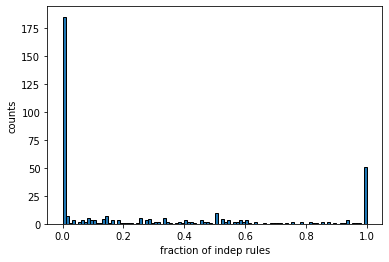

In [58]:
histogram(x2indepRulesFraction, x_axis='fraction of indep rules', bins=100)

In [59]:
# dict2csv(x2indepRulesFraction, 'xgroup2IndepRulesFraction.csv')

## What about fraction of reactions, not rules?

In [60]:
# fraction
def numIndepReactionWith(xgroup, rn2rules):
    result = {'indep':[], 'total':[]}
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:
                if xgroup in rule:
                    result['indep'].append(reaction)
                    result['total'].append(reaction)
            elif xgroup in rule:
                result['total'].append(reaction)
    return result
# returns result = {'indep':[R1, R2], 'total':[R3, R4, R5]}

In [61]:
x2indepTotal = {}
for xgroup in xgroup2ns.keys():
    x2indepTotal[xgroup] = numIndepReactionWith(xgroup, rn2rules)

In [62]:
x2fractionIndep = {}
for xgroup in xgroup2ns.keys():
    x2fractionIndep[xgroup] = len(x2indepTotal[xgroup]['indep'])/len(x2indepTotal[xgroup]['total'])

In [63]:
x2fractionIndep

{'102': 0.0,
 '3086': 1.0,
 '4022': 0.0,
 '3579': 0.0,
 '5100': 0.0,
 '2005': 0.3984375,
 '285': 1.0,
 '2010': 0.3333333333333333,
 '4952': 0.0,
 '4295': 1.0,
 '221': 0.33815028901734107,
 '611': 0.0,
 '4110': 0.16666666666666666,
 '7528': 0.40625,
 '868': 0.9166666666666666,
 '301': 0.25925925925925924,
 '184': 0.0,
 '7553': 0.6666666666666666,
 '1077': 0.0,
 '7556': 0.0,
 '4017': 0.0,
 '313': 0.0,
 '4019': 0.06666666666666667,
 '3687': 0.0,
 '325': 0.039301310043668124,
 '6096': 0.0,
 '7549': 1.0,
 '177': 0.0,
 '7601': 0.0,
 '3257': 0.0,
 '4028': 0.0,
 '131': 0.5333333333333333,
 '199': 0.0,
 '7536': 0.0,
 '3651': 0.0,
 '258': 0.0,
 '4035': 0.0,
 '214': 0.0,
 '7512': 0.9532019704433498,
 '867': 1.0,
 '10': 0.6023564064801178,
 '3978': 0.8571428571428571,
 '243': 0.1934156378600823,
 '1137': 0.0,
 '6051': 0.0,
 '3323': 0.0,
 '7539': 1.0,
 '323': 0.5954198473282443,
 '4018': 0.0,
 '107': 0.2714285714285714,
 '7561': 0.8947368421052632,
 '2487': 0.13989637305699482,
 '3016': 0.088082901

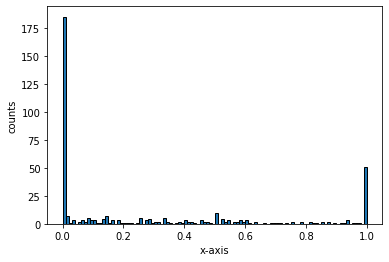

In [64]:
histogram(x2fractionIndep, bins=100)

In [65]:
# dict2csv(x2fractionIndep, 'xgroup2indepRxnFraction.csv')

In [66]:
setIndepX = set()
for x, frac in x2fractionIndep.items():
    if frac > 0:  # independent
        if x != 'spontaneous':
            setIndepX.add(x)

In [67]:
setIndepX

{'1',
 '10',
 '101',
 '107',
 '108',
 '109',
 '11',
 '1119',
 '12',
 '129',
 '131',
 '132',
 '133',
 '136',
 '139',
 '141',
 '146',
 '149',
 '150',
 '158',
 '159',
 '164',
 '172',
 '180',
 '185',
 '2',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2010',
 '2011',
 '2012',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '217',
 '219',
 '220',
 '221',
 '222',
 '223',
 '230',
 '231',
 '232',
 '235',
 '236',
 '237',
 '239',
 '241',
 '243',
 '244',
 '246',
 '247',
 '2484',
 '2485',
 '2486',
 '2487',
 '2492',
 '2498',
 '2500',
 '257',
 '262',
 '266',
 '276',
 '278',
 '281',
 '282',
 '283',
 '285',
 '286',
 '297',
 '298',
 '300',
 '3009',
 '301',
 '3016',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '3076',
 '3086',
 '309',
 '312',
 '314',
 '315',
 '3156',
 '316',
 '319',
 '3207',
 '321',
 '323',
 '324',
 '3249',
 '325',
 '327',
 '328',
 '330',
 '331',
 '3371',
 '3447',
 '371',
 '374',
 '3740',
 '375',
 '3754',
 '3883',
 '3896',
 '3978',
 '4019',
 '4021'

In [68]:
len(setIndepX)

213

In [69]:
# potential clusters?
set(group1) - setIndepX

{'148', '184', '218', '253', '3997', '4011', '4952', '4953', '602', '7544'}

### Group1

In [70]:
len(set(group1) & setIndepX)

27

In [71]:
len(set(group1))

37

In [72]:
len(set(group1) & setIndepX) / len(set(group1))

0.7297297297297297

### Group 2

In [73]:
len(set(group2) & setIndepX)

186

In [74]:
len(set(group2))

359

In [75]:
len(set(group2) & setIndepX) / len(set(group2))

0.5181058495821727

# Stacked bar chart

In [76]:
# categories =     ['All', 'I', 'II']
# indep_values =     [213, 27, 186]
# not_indep_values = [184, 10, 174]

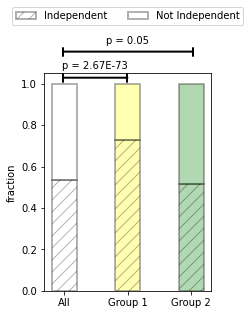

In [77]:
# Data
categories = ['All', 'Group 1', 'Group 2']
indep_values = [213/397, 27/37, 186/360]
not_indep_values = [184/397, 10/37, 174/360]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='Independent', linewidth=2, color=['white', 'yellow', 'green'], edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='Not Independent', linewidth=2, color=['white', 'yellow', 'green'], edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square: 2.66954E-73 (1 vs. all); 0.05 (2 vs. all)
ax.annotate('p = 2.67E-73', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
ax.annotate('p = 0.05', xy=(0.500, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))


# Show the plot
# plt.savefig('indepFraction_bar.png', bbox_inches='tight')

plt.show()


0.7421198957701578


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/1359199598.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])


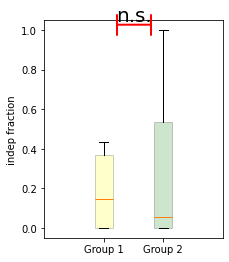

In [78]:
keys, data1, data2 = todata(x2fractionIndep, xgroup2sub1500)  # 10
keys, data3, data4 = todata(x2fractionIndep, xgroup2sup1500)  # 387
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
if p_value < 0.001:
    significance_text = '***'
elif p_value < 0.01:
    significance_text = '**'
elif p_value < 0.05:
    significance_text = '*'
else:
    significance_text = 'n.s.'
ax.annotate(significance_text, xy=(0.505, 1.02), xycoords='axes fraction', ha='center', va='center', fontsize=20, color='black')
ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=1, widthB=1, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('indep fraction')
# plt.savefig('boxplot_ds.png', bbox_inches='tight')
plt.show()

# Boxplots

In [79]:
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
xgroup2ds_ab = csv2dict(ab_path)

print(len(xgroup2ds_ab))
print(len(group1))
print(len(group2))

2230
37
359


## Boxplot - distribution score

7.912337874012595e-14


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/238368941.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])


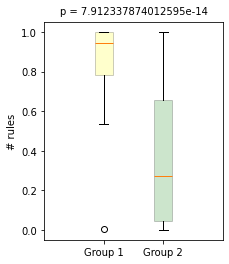

In [80]:
keys, data1, data2 = todata(xgroup2ds_ab, groupOne2ns) 
keys, data3, data4 = todata(xgroup2ds_ab, groupTwo2ns)  
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)
    
# sns.stripplot(data=[class1ds, class2ds], color='black', size=2, jitter=True, ax=ax)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
# ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
#            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.5, widthB=0.5, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('# rules')
# plt.savefig('boxplot_numRules.png', bbox_inches='tight')
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/1790292274.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


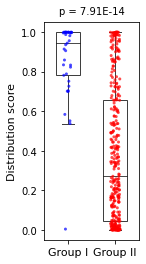

In [81]:
keys, data1, data2 = todata(xgroup2ds_ab, groupOne2ns) 
keys, data3, data4 = todata(xgroup2ds_ab, groupTwo2ns)

group1ds = np.array(data1)
group2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.7)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2.svg', dpi=300, bbox_inches = 'tight')
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/3217123323.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


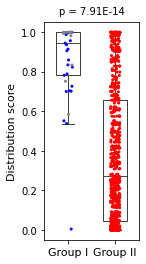

In [82]:
# Color first10 differently

keys, data5, data6 = todata(xgroup2ds_ab, xgroup2sub1500)
first10ds = np.array(data5)

group1minus10 = set(data1) - set(data5)
group1minus10ds = np.array(list(group1minus10))

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)
colors = ['gray', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2_first10_after.svg', dpi=300, bbox_inches = 'tight')
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/3173293.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


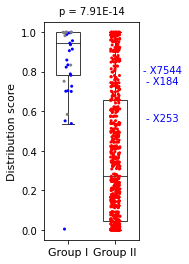

In [85]:
# annotate folds

keys, data5, data6 = todata(xgroup2ds_ab, xgroup2sub1500)
first10ds = np.array(data5)

group1minus10 = set(data1) - set(data5)
group1minus10ds = np.array(list(group1minus10))

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)
colors = ['gray', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)

# annotate demoted folds:
for x in {'184', '253', '7544'}:
    plt.text(2, xgroup2ds_ab[x], x2name.get(x, f"- X{x}"), ha='center', va='bottom', color='blue')

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2_first10_after_annotated.svg', dpi=300, bbox_inches = 'tight')
plt.show()

## bottom outlier in boxplot Group 1

In [86]:
for x in group1:
    if xgroup2ds_ab[x] < 0.6:
        print(x, xgroup2ds_ab[x], groupOne2ns[x])

875 0.5517578444971232 2833
4953 0.5843828224868748 457
3997 0.004198171025249323 3305
253 0.538151559161858 3040


In [87]:
# folds that moved to group2

for x in group1_old - set(group1):
    print(x, xgroup2ds_ab[x], groupTwo2ns[x])

In [88]:
print(xgroup2ns['3997'])  # ns = 3305
print(x2rulesNum['3997'])  # rulesNum = 1

3305
1


In [89]:
# x2rxn['3997']
# >> ['R03877']

In [90]:
rn2rules['R03877']  # {frozenset({'109', '148', '2004', '2007', '3997'})}

{frozenset({'109', '148', '2004', '2007', '3997'})}

In [91]:
# first committed step of chlorophyll biosynthesis
# and is a branchpoint of two major routes in the tetrapyrrole pathway.

# X3997 is the LAST Group 1 fold, with ns = 3305 (highest in Group 1)

In [92]:
np.max(list(groupOne2ns.values()))

3305

In [93]:
for x, ns in groupOne2ns.items():
    if ns == 3305:
        print(x, ns)

3997 3305


## Boxplot - # rules

In [94]:
rule_path = '../data/assets/xgroup2/xgroup2rulesNum.csv'
xgroup2numRules = csv2dict(rule_path)
print(len(xgroup2numRules))

397


1.375093450811484e-08


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/818810877.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])


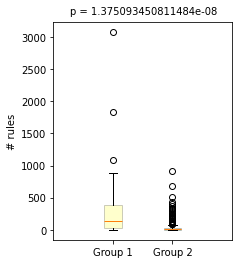

In [95]:
keys, data1, data2 = todata(xgroup2numRules, groupOne2ns) 
keys, data3, data4 = todata(xgroup2numRules, groupTwo2ns)  
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
# ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
#            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.5, widthB=0.5, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('# rules')
# plt.savefig('boxplot_numRules.png', bbox_inches='tight')
plt.show()

## Boxplot - repetitiveness

In [96]:
rep_path = '../data/assets/xgroup2/xgroup2repetitiveness_v1.json'
with open(rep_path, 'r') as file:
    xgroup2rep = json.load(file)
print(len(xgroup2rep))

379


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2594/165569842.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])


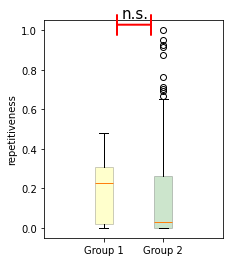

In [97]:
keys, data1, data2 = todata(xgroup2rep, xgroup2sub1500)  # 10
keys, data3, data4 = todata(xgroup2rep, xgroup2sup1500)  # 387
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Group 1', 'Group 2'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
if p_value < 0.001:
    significance_text = '***'
elif p_value < 0.01:
    significance_text = '**'
elif p_value < 0.05:
    significance_text = '*'
else:
    significance_text = 'n.s.'
ax.annotate(significance_text, xy=(0.51, 1.03), xycoords='axes fraction', ha='center', va='center', fontsize=15, color='black')
ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=1, widthB=1, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('repetitiveness')
# plt.savefig('boxplot_repetitiveness.png', bbox_inches='tight')
plt.show()

# Check if the group1 vs. group2 LOO networks include oxygen or not

In [98]:
for x in group1:
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00007', 'NO OXY')}")

X2005: NO OXY
X4952: NO OXY
X184: NO OXY
X325: NO OXY
X3016: NO OXY
X2003: NO OXY
X2002: NO OXY
X7523: NO OXY
X328: NO OXY
X875: NO OXY
X602: NO OXY
X2486: NO OXY
X212: NO OXY
X4011: NO OXY
X7574: NO OXY
X218: NO OXY
X2004: NO OXY
X304: NO OXY
X7584: NO OXY
X206: NO OXY
X4953: NO OXY
X1: NO OXY
X3997: NO OXY
X7577: NO OXY
X148: NO OXY
X7501: NO OXY
X7579: NO OXY
X2007: NO OXY
X253: NO OXY
X7544: NO OXY
X101: NO OXY
X297: NO OXY
X327: NO OXY
X330: NO OXY
X141: NO OXY
X109: NO OXY
X2492: NO OXY


In [99]:
for x in group2:
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00007', 'NO OXY')}")

X102: 49
X3086: 49
X4022: 49
X3579: 49
X5100: 49
X285: 49
X2010: 49
X4295: 49
X221: 50
X611: 49
X4110: 49
X7528: 49
X868: 49
X301: 49
X7553: 49
X1077: 49
X7556: 49
X4017: 49
X313: 49
X4019: 49
X3687: 49
X6096: 49
X7549: 49
X177: 49
X7601: 49
X3257: 49
X4028: 49
X131: 49
X199: 49
X7536: 49
X3651: 49
X258: 49
X4035: 49
X214: 49
X7512: 49
X867: 49
X10: 49
X3978: 49
X243: 49
X1137: 49
X6051: 49
X3323: 49
X7539: 49
X323: 49
X4018: 49
X107: 49
X7561: 49
X2487: 49
X7602: 49
X309: 49
X3001: 49
X146: 49
X387: 49
X282: 49
X283: 49
X4178: 49
X144: 49
X6166: 49
X244: 49
X4159: 49
X217: 49
X5084: 49
X7546: 49
X3500: 49
X3599: 49
X4076: 49
X7517: 49
X3304: 49
X3994: 49
X3371: 49
X7580: 49
X806: 49
X842: 49
X236: 49
X279: 49
X4054: 49
X1144: 49
X650: 49
X528: 49
X3752: 49
X3654: 49
X3321: 49
X241: 49
X3754: 49
X262: 49
X3686: 49
X7516: 49
X623: 49
X5: 49
X7513: 49
X232: 49
X3858: 49
X286: 49
X2011: 49
X4049: 49
X7581: 52
X3076: 49
X314: 49
X3264: 49
X312: 49
X159: 49
X303: 49
X632: 49
X4335: 49
X3456

# Check if the first10 vs. other LOO networks include ATP (NAD+) or not

In [100]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}

In [101]:
print('X       ns      ATP?')
print('---------------------')
for x in first10:
    print(f"X{x}:  {xgroup2ns[x]}   {loo[x].cpds_subiter[1].get('C00002', 'N/A')}")
    
# ATP boundary is around between ns=474 ~ ns=575

X       ns      ATP?
---------------------
X602:  457   N/A
X4952:  457   N/A
X325:  555   20
X2003:  1014   20
X2005:  645   20
X4953:  457   N/A
X206:  454   N/A
X218:  163   N/A
X2002:  155   N/A
X2007:  423   N/A


In [102]:
# check !(first10)
for x in set(group2) | (set(group1) - first10):
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00002', 'NO ATP')}")

X3994: 20
X199: 20
X205: 20
X5100: 20
X2004: 20
X283: 20
X5: 20
X262: 20
X3294: 20
X7556: 20
X387: 20
X7534: 20
X146: 20
X246: 20
X4081: 20
X1143: 20
X275: 20
X4983: 20
X7551: 20
X147: 20
X2010: 20
X7579: 20
X7553: 20
X5104: 20
X4160: 20
X4114: 20
X103: 20
X7501: 20
X3117: 20
X3688: 20
X2006: 20
X300: 20
X7572: 20
X881: 20
X62: 20
X3579: 20
X4020: 20
X7602: 20
X7517: 20
X184: 20
X7520: 20
X4048: 20
X7584: 20
X309: 20
X331: 20
X276: 20
X810: 20
X7573: 20
X281: 20
X313: 20
X6075: 20
X4004: 20
X640: 20
X4046: 20
X7546: 20
X805: 20
X7564: 20
X3993: 20
X154: 20
X4194: 20
X4159: 20
X7595: 20
X7589: 20
X3009: 20
X3794: 20
X7604: 20
X650: 20
X4971: 20
X136: 20
X3896: 20
X869: 20
X6094: 20
X7540: 20
X3651: 20
X1119: 20
X4272: 20
X7552: 20
X2485: 20
X3623: 20
X177: 20
X3978: 20
X243: 20
X258: 20
X236: 20
X69: 20
X149: 20
X219: 20
X7561: 20
X301: 20
X4019: 20
X6166: 20
X303: 20
X632: 20
X7510: 20
X305: 20
X7536: 20
X2496: 20
X133: 20
X185: 20
X4294: 20
X2492: 20
X7588: 20
X813: 20
X223: 20
X7515:

In [103]:
print('X       ns      NAD?')
print('---------------------')
for x in first10:
    print(f"X{x}  {xgroup2ns[x]}   {loo[x].cpds_subiter[1].get('C00004', 'N/A')}")

X       ns      NAD?
---------------------
X602  457   N/A
X4952  457   N/A
X325  555   N/A
X2003  1014   22
X2005  645   N/A
X4953  457   N/A
X206  454   N/A
X218  163   N/A
X2002  155   N/A
X2007  423   N/A


In [104]:
for x in set(group2) | (set(group1) - first10):
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00004', 'NO NAD')}")

X3994: 22
X199: 22
X205: 22
X5100: 22
X2004: 22
X283: 22
X5: 22
X262: 22
X3294: 22
X7556: 22
X387: 22
X7534: 22
X146: 22
X246: 22
X4081: 22
X1143: 22
X275: 22
X4983: 22
X7551: 22
X147: 22
X2010: 22
X7579: 22
X7553: 22
X5104: 22
X4160: 22
X4114: 22
X103: 22
X7501: 22
X3117: 22
X3688: 22
X2006: 22
X300: 22
X7572: 22
X881: 22
X62: 22
X3579: 22
X4020: 22
X7602: 22
X7517: 22
X184: 22
X7520: 22
X4048: 22
X7584: 22
X309: 22
X331: 22
X276: 22
X810: 22
X7573: 22
X281: 22
X313: 22
X6075: 22
X4004: 22
X640: 22
X4046: 22
X7546: 22
X805: 22
X7564: 22
X3993: 22
X154: 22
X4194: 22
X4159: 22
X7595: 22
X7589: 22
X3009: 22
X3794: 22
X7604: 22
X650: 22
X4971: 22
X136: 22
X3896: 22
X869: 22
X6094: 22
X7540: 22
X3651: 22
X1119: 22
X4272: 22
X7552: 22
X2485: 22
X3623: 22
X177: 22
X3978: 22
X243: 22
X258: 22
X236: 22
X69: 22
X149: 22
X219: 22
X7561: 22
X301: 22
X4019: 22
X6166: 22
X303: 22
X632: 22
X7510: 22
X305: 22
X7536: 22
X2496: 22
X133: 22
X185: 22
X4294: 22
X2492: 22
X7588: 22
X813: 22
X223: 22
X7515:

In [105]:
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00010', 'NO CoA')}")

X602: foAve=106.619, NO CoA
X4952: foAve=106.619, NO CoA
X325: foAve=30.293, NO CoA
X2003: foAve=6.511, NO CoA
X2005: foAve=79.546, NO CoA
X4953: foAve=107.619, NO CoA
X206: foAve=30.341, NO CoA
X218: foAve=11.444, NO CoA
X2002: foAve=2.0, NO CoA
X2007: foAve=12.444, NO CoA


In [106]:
print('X       ns      CoA?')
print('---------------------')

for x in set(group2) | (set(group1) - first10):
    print(f"X{x}   {xgroup2ns[x]}   {loo[x].cpds_subiter[1].get('C00010', 'N/A')}")

X       ns      CoA?
---------------------
X3994   4290   32
X199   4289   32
X205   4127   32
X5100   4291   32
X2004   2710   32
X283   4291   32
X5   4091   32
X262   4291   32
X3294   4291   32
X7556   4291   32
X387   4291   32
X7534   4279   32
X146   4270   32
X246   4271   32
X4081   4291   32
X1143   4291   32
X275   4291   32
X4983   4281   32
X7551   4291   32
X147   4291   32
X2010   4289   32
X7579   3272   32
X7553   4249   32
X5104   4291   32
X4160   4291   32
X4114   4291   32
X103   4254   32
X7501   2236   32
X3117   4291   32
X3688   4279   32
X2006   4272   32
X300   4291   32
X7572   4291   32
X881   4291   32
X62   4291   32
X3579   4291   32
X4020   4291   32
X7602   4291   32
X7517   4291   32
X184   3046   32
X7520   4291   32
X4048   4291   32
X7584   3248   32
X309   4291   32
X331   4277   32
X276   4291   32
X810   4291   32
X7573   3814   32
X281   4269   32
X313   4291   32
X6075   4291   32
X4004   4290   32
X640   4290   32
X4046   4291   32
X7546   42

In [107]:
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00024', 'NO acetyl CoA')}")

X602: foAve=106.619, NO acetyl CoA
X4952: foAve=106.619, NO acetyl CoA
X325: foAve=30.293, NO acetyl CoA
X2003: foAve=6.511, NO acetyl CoA
X2005: foAve=79.546, NO acetyl CoA
X4953: foAve=107.619, NO acetyl CoA
X206: foAve=30.341, NO acetyl CoA
X218: foAve=11.444, NO acetyl CoA
X2002: foAve=2.0, NO acetyl CoA
X2007: foAve=12.444, NO acetyl CoA


# network size vs. #rules

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


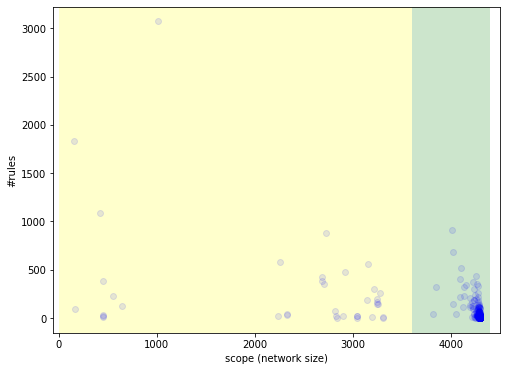

In [108]:
corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('scope (network size)')
ax.set_ylabel('#rules')

# plt.savefig('scatter_networkSize2numRules.png')
plt.show()

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


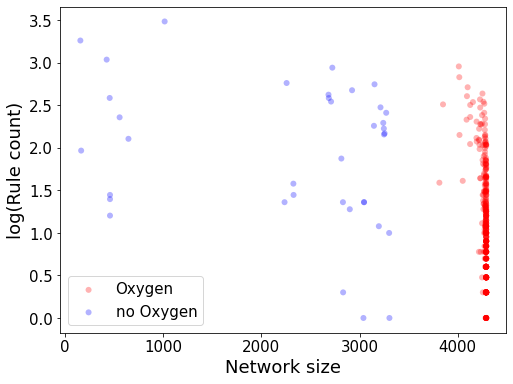

In [109]:
# annotate the presence/absence of Oxygen in the network

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(groupTwo2ns, x2rulesNum)
valid_keys, data3, data4 = todata(groupOne2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)


# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Rule count)', fontsize=18)
plt.tick_params(labelsize=15)
ax.legend(loc='lower left', labels=['Oxygen', 'no Oxygen'], fontsize=15)

# plt.savefig('scatter_networkSize2numRulesLog_after.svg', dpi=300, bbox_inches = 'tight')
plt.show()

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


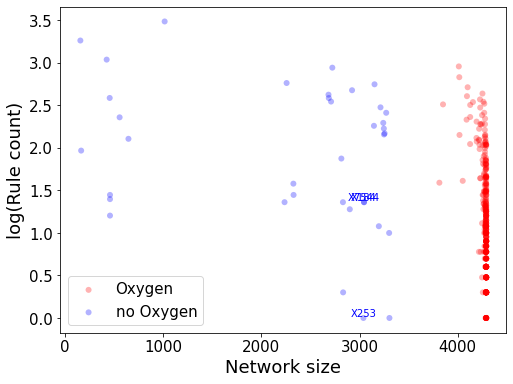

In [111]:
# annotate folds

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(groupTwo2ns, x2rulesNum)
valid_keys, data3, data4 = todata(groupOne2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)

# annotate demoted folds:
for x in {'184', '253', '7544'}:
    plt.text(groupTwo2ns[x], np.log10(x2rulesNum[x]), x2name.get(x, f"X{x}"), ha='center', va='bottom', color='blue')

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Rule count)', fontsize=18)
plt.tick_params(labelsize=15)
ax.legend(loc='lower left', labels=['Oxygen', 'no Oxygen'], fontsize=15)

# plt.savefig('scatter_ns2numRulesLog_after_annotated.svg', dpi=300, bbox_inches = 'tight')
plt.show()

In [112]:
print('X | scope | #rules')
print('----------------')
for key, value in xgroup2sub1500.items():
    print(key, value, x2rulesNum[key])

X | scope | #rules
----------------
2005 645 128
4952 457 25
325 555 229
2003 1014 3071
2002 155 1833
602 457 28
218 163 93
206 454 387
4953 457 16
2007 423 1093


# Co-dependence analysis

In [113]:
import itertools

In [114]:
# example

ex_dict = {}
ex_dict['a'] = {frozenset({'1', '2'})}  # ok
ex_dict['b'] = {frozenset({'1', '2'}), frozenset({'7'})}  # ok
ex_dict['c'] = {frozenset({'1', '2', '3'})}  # ok
ex_dict['d'] = {frozenset({'1'}), frozenset({'2'})}  # no
ex_dict['e'] = {frozenset({'1', '2'}), frozenset({'1'})}  # no 

In [115]:
combo = ['1', '2']

# original version where ex_dict['c'] was 'no'
# for reaction, rules in ex_dict.items():
#     contains_12 = frozenset(combo) in rules
#     contains_1 = frozenset(combo[0]) in rules
#     contains_2 = frozenset(combo[1]) in rules

#     if contains_12 and not contains_1 and not contains_2:
#         print(f"{reaction}: ok")
#     else:
#         print(f"{reaction}: no")

# new, relaxed version
for reaction, rules in ex_dict.items():
    
    contains_12 = frozenset(combo) in rules
    contains_1 = frozenset(combo[0]) in rules
    contains_2 = frozenset(combo[1]) in rules

    if contains_12 and not contains_1 and not contains_2:
        print(f"{reaction}: ok")
    elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
        print(f"{reaction}: ok2")
    else:
        print(f"{reaction}: no")

a: ok
b: ok
c: ok2
d: no
e: no


In [116]:
# 10C2

combo2rn = {}
for combo in itertools.combinations(xgroup2sub1500.keys(), 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules
        contains_1 = frozenset(combo[0]) in rules
        contains_2 = frozenset(combo[1]) in rules

        #original
        # if contains_12 and not contains_1 and not contains_2:
            # rn.append(reaction)
        
        # new
        if contains_12 and not contains_1 and not contains_2:
            rn.append(reaction)
        elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
            rn.append(reaction)
    combo2rn[combo] = rn

In [117]:
combo2rn

{('2005', '4952'): [],
 ('2005', '325'): [],
 ('2005', '2003'): ['R00575',
  'R00256',
  'R01395',
  'R10948',
  'R10949',
  'R11674',
  'R07641',
  'R00256_v2',
  'R01395_v2',
  'R07641_v1',
  'R10948_v2',
  'R00575_v1',
  'R11674_v1',
  'R00256_v1',
  'R10949_v1',
  'R10949_v2',
  'R10948_v1',
  'R01395_v1',
  'R07641_v2',
  'R00575_v2'],
 ('2005', '2002'): ['R00661', 'R12498', 'R00661_v1'],
 ('2005', '602'): [],
 ('2005', '218'): [],
 ('2005', '206'): ['R00575',
  'R00256',
  'R01395',
  'R10948',
  'R10949',
  'R07641',
  'R00256_v2',
  'R01395_v2',
  'R07641_v1',
  'R10948_v2',
  'R00575_v1',
  'R00256_v1',
  'R10949_v1',
  'R10949_v2',
  'R10948_v1',
  'R01395_v1',
  'R07641_v2',
  'R00575_v2'],
 ('2005', '4953'): [],
 ('2005', '2007'): ['R01231',
  'R01230',
  'R00575',
  'R08244',
  'R00256',
  'R01395',
  'R10948',
  'R10949',
  'R07641',
  'R00256_v2',
  'R01395_v2',
  'R07641_v1',
  'R10948_v2',
  'R00575_v1',
  'R00256_v1',
  'R10949_v1',
  'R10949_v2',
  'R10948_v1',
  'R0

In [118]:
combo2rnNum = {}
for key, values in combo2rn.items():
    combo2rnNum[key] = len(values)

In [119]:
combo2rnNum

{('2005', '4952'): 0,
 ('2005', '325'): 0,
 ('2005', '2003'): 20,
 ('2005', '2002'): 3,
 ('2005', '602'): 0,
 ('2005', '218'): 0,
 ('2005', '206'): 18,
 ('2005', '4953'): 0,
 ('2005', '2007'): 21,
 ('4952', '325'): 0,
 ('4952', '2003'): 0,
 ('4952', '2002'): 0,
 ('4952', '602'): 23,
 ('4952', '218'): 0,
 ('4952', '206'): 0,
 ('4952', '4953'): 13,
 ('4952', '2007'): 0,
 ('325', '2003'): 43,
 ('325', '2002'): 17,
 ('325', '602'): 0,
 ('325', '218'): 0,
 ('325', '206'): 38,
 ('325', '4953'): 0,
 ('325', '2007'): 1,
 ('2003', '2002'): 118,
 ('2003', '602'): 0,
 ('2003', '218'): 0,
 ('2003', '206'): 130,
 ('2003', '4953'): 0,
 ('2003', '2007'): 145,
 ('2002', '602'): 0,
 ('2002', '218'): 93,
 ('2002', '206'): 42,
 ('2002', '4953'): 0,
 ('2002', '2007'): 157,
 ('602', '218'): 0,
 ('602', '206'): 0,
 ('602', '4953'): 15,
 ('602', '2007'): 0,
 ('218', '206'): 0,
 ('218', '4953'): 0,
 ('218', '2007'): 0,
 ('206', '4953'): 0,
 ('206', '2007'): 56,
 ('4953', '2007'): 0}

In [122]:
print(combo2rnNum[('4952', '602')])
print(combo2rnNum[('4952', '4953')])
print(combo2rnNum[('602', '4953')])  # order switched; due to itertools randomness?

23
13
15


In [ ]:
# combo2rnNum[('602', '4952')] KeyError
# combo2rnNum[('4953', '602')] KeyError
# combo2rnNum[('4953', '4952')] KeyError

In [124]:
print(combo2rn[('602', '4953')])
print(combo2rn[('4952', '602')])

['R00259', 'R01086', 'R00697', 'R00737', 'R01083', 'R04559', 'R01082', 'R00490', 'R10286', 'R06132', 'R10286_v1', 'R00697_v1', 'R00737_v1', 'R01082_v1', 'R06132_v1']
['R00697', 'R00737', 'R01168', 'R01083', 'R11366', 'R11391', 'R04559', 'R01082', 'R11432', 'R00490', 'R03307', 'R11749', 'R00739', 'R10286', 'R06132', 'R10286_v1', 'R00697_v1', 'R11366_v1', 'R00739_v1', 'R00737_v1', 'R01082_v1', 'R06132_v1', 'R01168_v1']


In [125]:
print(rn2rules['R01086'])

{frozenset({'602', '4953', '213'}), frozenset({'602', '4953'})}


In [ ]:
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

In [126]:
for reaction in combo2rn[('4952', '602')]:
    print(rn2rules[reaction])

{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'7521', '2002'}), frozenset({'602', '4952'}), frozenset({'2003'}), frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952'})}
{frozenset({'602', '4952', '4953'})}
{frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
{frozenset({'7521', '2002'}), frozenset({'602', '4952', '4953'}), frozenset({'2003'}), frozenset({'602', '4952'})}
{frozenset({'602', '4952'})}


## Draw a network

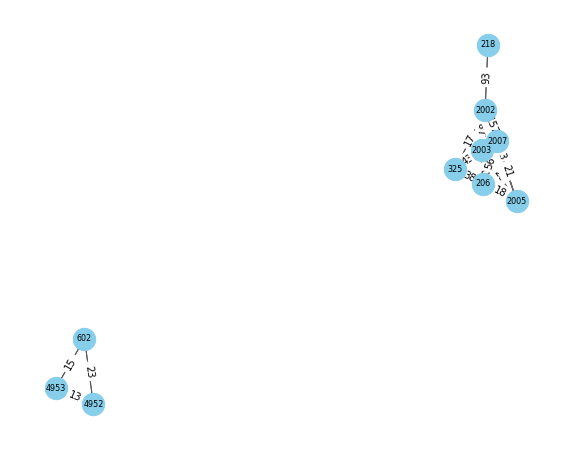

In [127]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
data = combo2rnNum

# Create a graph
G = nx.Graph()

# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=1000)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue", font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')  # Draw edges with alpha

nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network.png')
plt.show()

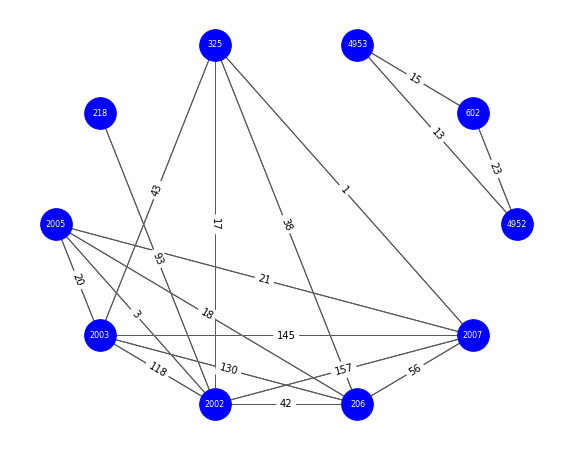

In [128]:
# Your data
data = combo2rnNum

# Create a graph
G = nx.Graph()


# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.shell_layout(G)  # Use shell_layout
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=1000, node_color="blue", font_size=8, ax=ax, font_color = 'white')
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network_shell.png')
plt.show()

In [129]:
# trio

trio = frozenset({'602', '4952', '4953'})
    # iterate through rn2rules
for reaction, rules in rn2rules.items():
    if trio in rules:
        print(reaction, rules)

# 13 rules exist with {'602', '4952', '4953'}, where 9 have no other rules

R00697 {frozenset({'602', '4952', '4953'})}
R00737 {frozenset({'602', '4952', '4953'})}
R01083 {frozenset({'602', '4952', '4953'})}
R04559 {frozenset({'602', '4952', '4953'})}
R01082 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R00490 {frozenset({'602', '4952', '4953'})}
R10286 {frozenset({'602', '4952', '4953'})}
R06132 {frozenset({'7521', '2002'}), frozenset({'602', '4952'}), frozenset({'2003'}), frozenset({'602', '4952', '4953'})}
R10286_v1 {frozenset({'602', '4952', '4953'})}
R00697_v1 {frozenset({'602', '4952', '4953'})}
R00737_v1 {frozenset({'602', '4952', '4953'})}
R01082_v1 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R06132_v1 {frozenset({'7521', '2002'}), frozenset({'602', '4952', '4953'}), frozenset({'2003'}), frozenset({'602', '4952'})}


## combo, but allow solo rule

In [130]:
# 10C2

comboLoose2rn = {}
for combo in itertools.combinations(xgroup2sub1500.keys(), 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules

        if contains_12:
            rn.append(reaction)
    comboLoose2rn[combo] = rn

In [131]:
comboLoose2rn

{('2005', '4952'): [],
 ('2005', '325'): [],
 ('2005', '2003'): [],
 ('2005', '2002'): ['R00661', 'R12498', 'R00661_v1'],
 ('2005', '602'): [],
 ('2005', '218'): [],
 ('2005', '206'): [],
 ('2005', '4953'): [],
 ('2005', '2007'): [],
 ('4952', '325'): [],
 ('4952', '2003'): [],
 ('4952', '2002'): [],
 ('4952', '602'): ['R01168',
  'R11366',
  'R11391',
  'R11432',
  'R03307',
  'R11749',
  'R00739',
  'R06132',
  'R11366_v1',
  'R00739_v1',
  'R06132_v1',
  'R01168_v1'],
 ('4952', '218'): [],
 ('4952', '206'): [],
 ('4952', '4953'): [],
 ('4952', '2007'): [],
 ('325', '2003'): [],
 ('325', '2002'): ['R03348', 'R01271'],
 ('325', '602'): [],
 ('325', '218'): [],
 ('325', '206'): [],
 ('325', '4953'): [],
 ('325', '2007'): [],
 ('2003', '2002'): ['R02722',
  'R02252',
  'R02511',
  'R01588',
  'R00362',
  'R00674',
  'R02340',
  'R01689',
  'R04319',
  'R12109',
  'R12110',
  'R12111',
  'R12620',
  'R12620_v1',
  'R01689_v1',
  'R02340_v1',
  'R02511_v3',
  'R01689_v2',
  'R02252_v2',
 

In [132]:
comboLoose2rnNum = {}
for key, values in combo2rn.items():
    comboLoose2rnNum[key] = len(values)

In [133]:
comboLoose2rnNum

{('2005', '4952'): 0,
 ('2005', '325'): 0,
 ('2005', '2003'): 20,
 ('2005', '2002'): 3,
 ('2005', '602'): 0,
 ('2005', '218'): 0,
 ('2005', '206'): 18,
 ('2005', '4953'): 0,
 ('2005', '2007'): 21,
 ('4952', '325'): 0,
 ('4952', '2003'): 0,
 ('4952', '2002'): 0,
 ('4952', '602'): 23,
 ('4952', '218'): 0,
 ('4952', '206'): 0,
 ('4952', '4953'): 13,
 ('4952', '2007'): 0,
 ('325', '2003'): 43,
 ('325', '2002'): 17,
 ('325', '602'): 0,
 ('325', '218'): 0,
 ('325', '206'): 38,
 ('325', '4953'): 0,
 ('325', '2007'): 1,
 ('2003', '2002'): 118,
 ('2003', '602'): 0,
 ('2003', '218'): 0,
 ('2003', '206'): 130,
 ('2003', '4953'): 0,
 ('2003', '2007'): 145,
 ('2002', '602'): 0,
 ('2002', '218'): 93,
 ('2002', '206'): 42,
 ('2002', '4953'): 0,
 ('2002', '2007'): 157,
 ('602', '218'): 0,
 ('602', '206'): 0,
 ('602', '4953'): 15,
 ('602', '2007'): 0,
 ('218', '206'): 0,
 ('218', '4953'): 0,
 ('218', '2007'): 0,
 ('206', '4953'): 0,
 ('206', '2007'): 56,
 ('4953', '2007'): 0}

In [135]:
print(comboLoose2rnNum[('4952', '602')])
print(comboLoose2rnNum[('4952', '4953')])
print(comboLoose2rnNum[('602', '4953')])

23
13
15


15


In [ ]:
# doesn't increase rnNum! these folds are definitely co-dep

# look for more trouples

In [136]:
troupleMaybe = set(group1) - setIndepX
troupleMaybe

{'148', '184', '218', '253', '3997', '4011', '4952', '4953', '602', '7544'}

In [137]:
# same as above, but with the new set

comboMaybe2rn = {}
for combo in itertools.combinations(troupleMaybe, 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules
        contains_1 = frozenset(combo[0]) in rules
        contains_2 = frozenset(combo[1]) in rules

        #original
        # if contains_12 and not contains_1 and not contains_2:
            # rn.append(reaction)
        
        # new
        if contains_12 and not contains_1 and not contains_2:
            rn.append(reaction)
        elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
            rn.append(reaction)
    comboMaybe2rn[combo] = rn

In [138]:
comboMaybe2rn

{('602', '4952'): ['R00697',
  'R00737',
  'R01168',
  'R01083',
  'R11366',
  'R11391',
  'R04559',
  'R01082',
  'R11432',
  'R00490',
  'R03307',
  'R11749',
  'R00739',
  'R10286',
  'R06132',
  'R10286_v1',
  'R00697_v1',
  'R11366_v1',
  'R00739_v1',
  'R00737_v1',
  'R01082_v1',
  'R06132_v1',
  'R01168_v1'],
 ('602', '3997'): [],
 ('602', '4011'): [],
 ('602', '4953'): ['R00259',
  'R01086',
  'R00697',
  'R00737',
  'R01083',
  'R04559',
  'R01082',
  'R00490',
  'R10286',
  'R06132',
  'R10286_v1',
  'R00697_v1',
  'R00737_v1',
  'R01082_v1',
  'R06132_v1'],
 ('602', '184'): [],
 ('602', '148'): [],
 ('602', '218'): [],
 ('602', '7544'): [],
 ('602', '253'): [],
 ('4952', '3997'): [],
 ('4952', '4011'): [],
 ('4952', '4953'): ['R00697',
  'R00737',
  'R01083',
  'R04559',
  'R01082',
  'R00490',
  'R10286',
  'R06132',
  'R10286_v1',
  'R00697_v1',
  'R00737_v1',
  'R01082_v1',
  'R06132_v1'],
 ('4952', '184'): [],
 ('4952', '148'): [],
 ('4952', '218'): [],
 ('4952', '7544')

In [139]:
comboMaybe2rnNum = {}
for key, values in comboMaybe2rn.items():
    comboMaybe2rnNum[key] = len(values)

In [140]:
comboMaybe2rnNum

{('602', '4952'): 23,
 ('602', '3997'): 0,
 ('602', '4011'): 0,
 ('602', '4953'): 15,
 ('602', '184'): 0,
 ('602', '148'): 0,
 ('602', '218'): 0,
 ('602', '7544'): 0,
 ('602', '253'): 0,
 ('4952', '3997'): 0,
 ('4952', '4011'): 0,
 ('4952', '4953'): 13,
 ('4952', '184'): 0,
 ('4952', '148'): 0,
 ('4952', '218'): 0,
 ('4952', '7544'): 0,
 ('4952', '253'): 0,
 ('3997', '4011'): 0,
 ('3997', '4953'): 0,
 ('3997', '184'): 0,
 ('3997', '148'): 1,
 ('3997', '218'): 0,
 ('3997', '7544'): 0,
 ('3997', '253'): 0,
 ('4011', '4953'): 0,
 ('4011', '184'): 0,
 ('4011', '148'): 0,
 ('4011', '218'): 0,
 ('4011', '7544'): 0,
 ('4011', '253'): 0,
 ('4953', '184'): 0,
 ('4953', '148'): 0,
 ('4953', '218'): 0,
 ('4953', '7544'): 0,
 ('4953', '253'): 0,
 ('184', '148'): 0,
 ('184', '218'): 0,
 ('184', '7544'): 21,
 ('184', '253'): 0,
 ('148', '218'): 0,
 ('148', '7544'): 0,
 ('148', '253'): 0,
 ('218', '7544'): 0,
 ('218', '253'): 0,
 ('7544', '253'): 0}

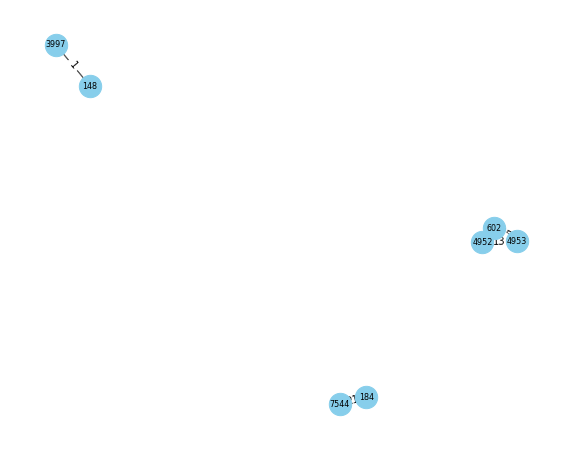

In [141]:
# Your data
data = comboMaybe2rnNum

# Create a graph
G = nx.Graph()

# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=1000)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue", font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')  # Draw edges with alpha

nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network.png')
plt.show()

# Unique reactions

In [142]:
def numRnWith(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRn += 1
                break
    return numRn

In [143]:
x2RnNum = {}
for xgroup in xgroup2ns.keys():
    x2RnNum[xgroup] = numRnWith(xgroup, rn2rules)

In [144]:
x2RnNum['2003']

2673

In [145]:
print(x2RnNum['602'], x2RnNum['4952'], x2RnNum['4953'])  # 25 23 15

25 23 15


In [146]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '4953' in rule:
            print(reaction, rules)
            break

R00259 {frozenset({'231', '3117'}), frozenset({'602', '4953', '213'}), frozenset({'213', '7531'}), frozenset({'213'})}
R01086 {frozenset({'602', '4953', '213'}), frozenset({'602', '4953'})}
R00697 {frozenset({'602', '4952', '4953'})}
R00737 {frozenset({'602', '4952', '4953'})}
R01083 {frozenset({'602', '4952', '4953'})}
R04559 {frozenset({'602', '4952', '4953'})}
R01082 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R00490 {frozenset({'602', '4952', '4953'})}
R10286 {frozenset({'602', '4952', '4953'})}
R06132 {frozenset({'7521', '2002'}), frozenset({'602', '4952'}), frozenset({'2003'}), frozenset({'602', '4952', '4953'})}
R10286_v1 {frozenset({'602', '4952', '4953'})}
R00697_v1 {frozenset({'602', '4952', '4953'})}
R00737_v1 {frozenset({'602', '4952', '4953'})}
R01082_v1 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R06132_v1 {frozenset({'7521', '2002'}), frozenset({'602', '4952', '4953'}), frozenset({'2003'}), frozenset({'602', '4952'})}


In [147]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '4952' in rule:
            print(reaction, rules)
            break

R00697 {frozenset({'602', '4952', '4953'})}
R00737 {frozenset({'602', '4952', '4953'})}
R01168 {frozenset({'602', '4952'})}
R01083 {frozenset({'602', '4952', '4953'})}
R11366 {frozenset({'602', '4952'})}
R11391 {frozenset({'602', '4952'})}
R04559 {frozenset({'602', '4952', '4953'})}
R01082 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R11432 {frozenset({'602', '4952'})}
R00490 {frozenset({'602', '4952', '4953'})}
R03307 {frozenset({'602', '4952'})}
R11749 {frozenset({'602', '4952'})}
R00739 {frozenset({'602', '4952'})}
R10286 {frozenset({'602', '4952', '4953'})}
R06132 {frozenset({'7521', '2002'}), frozenset({'602', '4952'}), frozenset({'2003'}), frozenset({'602', '4952', '4953'})}
R10286_v1 {frozenset({'602', '4952', '4953'})}
R00697_v1 {frozenset({'602', '4952', '4953'})}
R11366_v1 {frozenset({'602', '4952'})}
R00739_v1 {frozenset({'602', '4952'})}
R00737_v1 {frozenset({'602', '4952', '4953'})}
R01082_v1 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '495

In [148]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '602' in rule:
            print(reaction, rules)
            break

R00259 {frozenset({'231', '3117'}), frozenset({'602', '4953', '213'}), frozenset({'213', '7531'}), frozenset({'213'})}
R01086 {frozenset({'602', '4953', '213'}), frozenset({'602', '4953'})}
R00697 {frozenset({'602', '4952', '4953'})}
R00737 {frozenset({'602', '4952', '4953'})}
R01168 {frozenset({'602', '4952'})}
R01083 {frozenset({'602', '4952', '4953'})}
R11366 {frozenset({'602', '4952'})}
R11391 {frozenset({'602', '4952'})}
R04559 {frozenset({'602', '4952', '4953'})}
R01082 {frozenset({'2487', '2485'}), frozenset({'602', '4952', '4953'})}
R11432 {frozenset({'602', '4952'})}
R00490 {frozenset({'602', '4952', '4953'})}
R03307 {frozenset({'602', '4952'})}
R11749 {frozenset({'602', '4952'})}
R00739 {frozenset({'602', '4952'})}
R10286 {frozenset({'602', '4952', '4953'})}
R06132 {frozenset({'7521', '2002'}), frozenset({'602', '4952'}), frozenset({'2003'}), frozenset({'602', '4952', '4953'})}
R10286_v1 {frozenset({'602', '4952', '4953'})}
R00697_v1 {frozenset({'602', '4952', '4953'})}
R1136

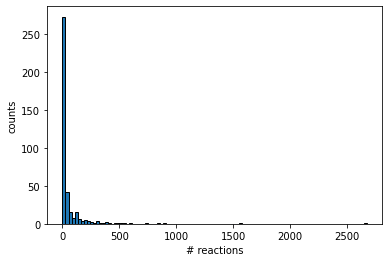

In [149]:
histogram(x2RnNum, x_axis = '# reactions', bins=100)

In [150]:
# R: {{2002}, {2002, 2}, {2002, 3}}
# then this reaction is "unique" to 2002

In [151]:
def numUniqueRnWith(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1
                    
        if counter == len(rules):
            numRn += 1
    return numRn

In [152]:
x2uniqueRnNum = {}
for xgroup in xgroup2ns.keys():
    x2uniqueRnNum[xgroup] = numUniqueRnWith(xgroup, rn2rules)

In [153]:
x2uniqueRnNum

{'102': 20,
 '3086': 1,
 '4022': 2,
 '3579': 3,
 '5100': 7,
 '2005': 70,
 '285': 0,
 '2010': 12,
 '4952': 19,
 '4295': 1,
 '221': 249,
 '611': 4,
 '4110': 1,
 '7528': 14,
 '868': 3,
 '301': 41,
 '184': 7,
 '7553': 3,
 '1077': 0,
 '7556': 3,
 '4017': 8,
 '313': 4,
 '4019': 5,
 '3687': 14,
 '325': 165,
 '6096': 1,
 '7549': 4,
 '177': 0,
 '7601': 2,
 '3257': 0,
 '4028': 1,
 '131': 21,
 '199': 4,
 '7536': 0,
 '3651': 3,
 '258': 0,
 '4035': 0,
 '214': 0,
 '7512': 383,
 '867': 17,
 '10': 426,
 '3978': 14,
 '243': 196,
 '1137': 14,
 '6051': 4,
 '3323': 4,
 '7539': 4,
 '323': 118,
 '4018': 20,
 '107': 42,
 '7561': 19,
 '2487': 114,
 '3016': 348,
 '7602': 2,
 '309': 4,
 '3001': 1,
 '146': 36,
 '2003': 2176,
 '387': 1,
 '282': 3,
 '283': 3,
 '4178': 2,
 '2002': 1162,
 '7523': 14,
 '144': 0,
 '6166': 7,
 '328': 10,
 '244': 412,
 '4159': 6,
 '217': 182,
 '5084': 9,
 '7546': 0,
 '3500': 4,
 '3599': 2,
 '4076': 1,
 '7517': 18,
 '3304': 4,
 '3994': 1,
 '3371': 0,
 '7580': 2,
 '806': 7,
 '842': 2,
 '2

In [154]:
x2uniqueRnNum['2002']

1162

In [155]:
# dict2csv(x2uniqueRnNum, 'xgroup2uniqueRnNum.csv')

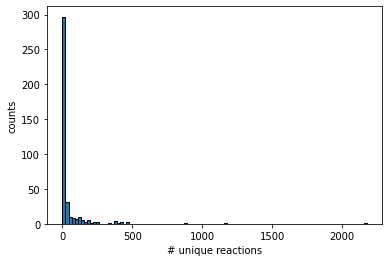

In [156]:
histogram(x2uniqueRnNum, x_axis = '# unique reactions', bins=100)

In [157]:
# divide each y-value (unique) with total #reactions catalyzed by that fold

def numUniqueRnWith2(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1
                    
        if counter == len(rules):
            numRn += 1
    return numRn / numRnWith(xgroup, rn2rules)

In [158]:
x2uniqueRnNum2 = {}
for xgroup in xgroup2ns.keys():
    x2uniqueRnNum2[xgroup] = numUniqueRnWith2(xgroup, rn2rules)

In [159]:
x2uniqueRnNum2

{'102': 0.37037037037037035,
 '3086': 0.3333333333333333,
 '4022': 1.0,
 '3579': 1.0,
 '5100': 0.5384615384615384,
 '2005': 0.6363636363636364,
 '285': 0.0,
 '2010': 0.7058823529411765,
 '4952': 0.8260869565217391,
 '4295': 1.0,
 '221': 0.7545454545454545,
 '611': 1.0,
 '4110': 0.25,
 '7528': 0.7,
 '868': 0.25,
 '301': 0.43157894736842106,
 '184': 0.3333333333333333,
 '7553': 1.0,
 '1077': 0.0,
 '7556': 0.5,
 '4017': 0.8,
 '313': 1.0,
 '4019': 0.3333333333333333,
 '3687': 0.5,
 '325': 0.812807881773399,
 '6096': 1.0,
 '7549': 1.0,
 '177': 0.0,
 '7601': 1.0,
 '3257': 0.0,
 '4028': 0.2,
 '131': 0.3,
 '199': 1.0,
 '7536': 0.0,
 '3651': 1.0,
 '258': 0.0,
 '4035': 0.0,
 '214': 0.0,
 '7512': 0.9433497536945813,
 '867': 1.0,
 '10': 0.7123745819397993,
 '3978': 1.0,
 '243': 0.8270042194092827,
 '1137': 0.5384615384615384,
 '6051': 1.0,
 '3323': 0.045454545454545456,
 '7539': 1.0,
 '323': 0.9291338582677166,
 '4018': 0.6451612903225806,
 '107': 0.7636363636363637,
 '7561': 1.0,
 '2487': 0.82014

In [160]:
# dict2csv(x2uniqueRnNum2, 'xgroup2uniqueRnFraction.csv')

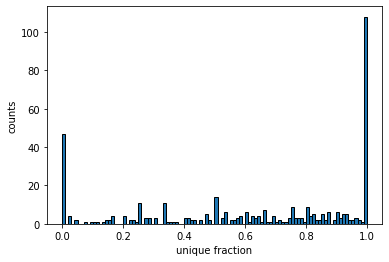

In [161]:
histogram(x2uniqueRnNum2, x_axis = 'unique fraction', bins=100)